In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

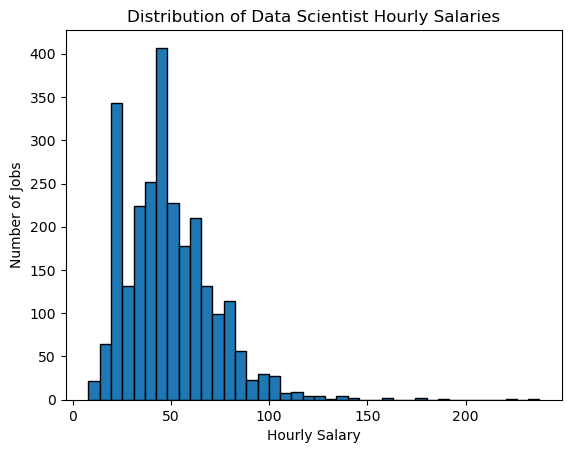

In [25]:
job = 'Data Scientist'

df_job = df[df['job_title_short'] == job].copy()
df_job = df_job.dropna(subset=['salary_hour_avg'])
df_job['salary_hour_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlabel('Hourly Salary')
plt.ylabel('Number of Jobs')
plt.title(f'Distribution of {job} Hourly Salaries')
plt.show()

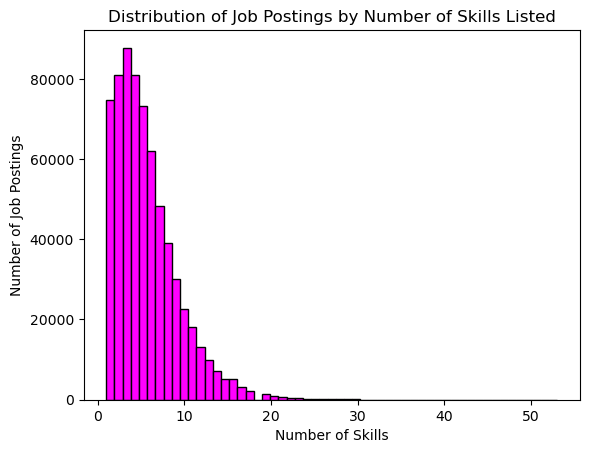

In [27]:
df_skills = df.copy().dropna(subset='job_skills')
df_skills['skills_number'] = df_skills['job_skills'].apply(len)
df_skills['skills_number'].plot(kind='hist', bins=55, color='magenta', edgecolor='black')
plt.title('Distribution of Job Postings by Number of Skills Listed')
plt.xlabel('Number of Skills')
plt.ylabel('Number of Job Postings')
plt.show()

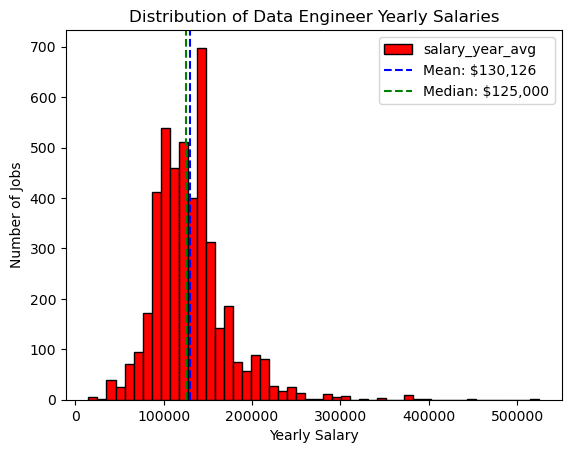

In [44]:
job = 'Data Engineer'

df_job = df[df['job_title_short'] == job].copy()
df_job = df_job.dropna(subset='salary_year_avg')

mean_salary = df_job['salary_year_avg'].mean()
median_salary = df_job['salary_year_avg'].median()

df_job['salary_year_avg'].plot(kind='hist', bins=50, color='red', edgecolor='black')

plt.axvline(mean_salary, color='blue', linestyle='dashed', label=f'Mean: ${mean_salary:,.0f}')
plt.axvline(median_salary, color='green', linestyle='dashed', label=f'Median: ${median_salary:,.0f}')

plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title(f'Distribution of {job} Yearly Salaries')

plt.legend()
plt.show()